In [15]:
import pandas as pd
import json
from pathlib import Path
from elasticsearch import Elasticsearch, helpers
from pprint import pprint
import matplotlib.pyplot as plt
import seaborn as sns
import re
from IPython.display import Markdown, display

In [16]:
#Load Dyanmic Paths
BASE_DIR = Path.cwd()                        
DATA_DIR = BASE_DIR / "IR2025" or BASE_DIR / "IR2025" / "IR2025"
CSV_PATH = DATA_DIR / "documents.csv"
JSONL_PATH = DATA_DIR / "documents.jsonl"
QUERIES_PATH = DATA_DIR / "queries.csv"
QRELS_PATH = DATA_DIR / "qrels.csv"

In [17]:
# Load CSV File
try:
    df = pd.read_csv(CSV_PATH, encoding="utf-8")
except FileNotFoundError:
    raise SystemExit(f"File not found: {CSV_PATH}")
except Exception as e:
    raise SystemExit(f"Error reading CSV: {e}")

In [18]:
# Display Columns and Document Count
print(f"CSV loaded successfully → {len(df)} documents found")
print(f"Columns detected: {list(df.columns)}")

CSV loaded successfully → 18316 documents found
Columns detected: ['ID', 'Text']


In [19]:
# Validate Required Columns
required_cols = {"ID", "Text"}
missing = required_cols - set(df.columns)
if missing:
    raise SystemExit(f"Missing expected columns: {missing}")

In [20]:
def preprocess(s):
    if not isinstance(s, str):
        return ""
    s = s.strip()
    s = re.sub(r"\s+", " ", s)                       # collapse spaces/newlines
    s = re.sub(r"http\S+|www\.\S+", "<URL>", s)      # replace URLs
    s = re.sub(r"\S+@\S+", "<EMAIL>", s)             # replace emails
    s = re.sub(r"<[^>]+>", " ", s)                   # remove HTML tags
    s = ''.join(ch for ch in s if ord(ch) >= 32)     # remove control chars
    s = re.sub(r"['\"]", "", s)                      # remove single and double quotes
    return s.strip()


df = df.dropna(subset=["Text"])
df["Text"] = df["Text"].astype(str).map(preprocess)

In [21]:
# Convert to JSONL
records_written = 0
with open(JSONL_PATH, "w", encoding="utf-8") as f:
    for _, row in df.iterrows():
        record = {
            "id": row["ID"],     
            "text": row["Text"]
        }
        json_line = json.dumps(record, ensure_ascii=False)
        f.write(json_line + "\n")
        records_written += 1

print(f"Converted {records_written} rows → JSONL format")
print(f"Output saved at: {JSONL_PATH.resolve()}")

Converted 18316 rows → JSONL format
Output saved at: C:\Users\perik\Downloads\Semantic-Information-Retrieval-System-ElasticSearch-FAISS-Transformers-\IR2025\documents.jsonl


In [22]:
class Search:
    def __init__(self):
        self.es = Elasticsearch("http://127.0.0.1:9200")
        client_info = self.es.info()
        print('Connected to Elasticsearch!')
        pprint(client_info.body)

    #Return instance
    def get_es(self):
        return self.es

    #Creates empty index with the parameters we feed
    def create_index(self):
        index_settings = {
            "settings": {
                "similarity": {
                    "default": {"type": "BM25"}
                },
                "analysis": {
                    "analyzer": {
                        "default": {
                            "type": "standard"
                        }
                    }
                }
            },
            "mappings": {
                "properties": {
                    "id": {"type": "keyword"},
                    "text": {"type": "text", "analyzer": "standard"}
                }
            }
        }

        self.es.indices.create(index='ir2025', body=index_settings)
        print("Index created with English analyzer and BM25 similarity.")

    #Insert single document
    def insert_document(self, document):
        return self.es.index(index='ir2025', document=document)

    #Insert multiple indexes
    def insert_documents(self, documents):
        operations = []
        for document in documents:
            operations.append({'index': {'_index': 'ir2025'}})
            operations.append(document)

        result = self.es.bulk(operations=operations)
        print("Insertion finished.")
        print(result)

    #Deletes index
    def delete_index(self, index_name="ir2025"):
        if self.es.indices.exists(index=index_name):
            self.es.indices.delete(index=index_name)
            print(f"Index '{index_name}' deleted successfully.")
        else:
            print(f"Index '{index_name}' does not exist.")

    #Check if index exists
    def exists(self, index_name="ir2025"):
        try:
            return self.es.indices.exists(index=index_name)
        except Exception as e:
            print(f"Error checking if index exists: {e}")
            return False

    #Helper function for bulk indexing
    def generate_actions(self, jsonl_path, index_name):
        with open(jsonl_path, encoding="utf-8") as f:
            for i, line in enumerate(f):
                yield {
                    "_index": index_name,
                    "_id": i,
                    "_source": json.loads(line)
                }

    #Bulk index docs
    def index_documents(self, jsonl_path, index_name):
        actions = self.generate_actions(jsonl_path, index_name)
        success, _ = helpers.bulk(self.get_es(), actions)
        print(f"Successfully indexed {success} documents into '{index_name}'")

    #Runs query
    def search_query(self, query_text, k=10, index_name="ir2025"):
        try:
            resp = self.es.search(
                index=index_name,
                query={"match": {"text": {"query": query_text}}},
                size=k
            )
            return resp["hits"]["hits"]
        except Exception as e:
            print(f"Error executing search query: {e}")
            return []


# ------------------------------------------------------------------
class Evaluation:
    def __init__(self, search_client):
        self.search = search_client
        
    #Loads file
    def load_file(self, filename):
        df = pd.read_csv(filename, encoding="utf-8")
        print("Loaded queries successfully")
        return df

    #Runs queries and keep results
    def generate_file_results(self, dir, filename):
        df_queries = self.load_file(filename)
        for k in [20, 30, 50]:
            results_path = dir / f"results_{k}.txt"
            with open(results_path, "w", encoding="utf-8") as f:
                for _, row in df_queries.iterrows():
                    qid = str(row[0]) 
                    qtext = str(row[1])
                    
                    results = self.search.search_query(qtext, k) 
                    
                    for rank, hit in enumerate(results, start=1):
                        docid = hit["_source"]["id"]
                        score = hit["_score"]
                        f.write(f"{qid} Q0 {docid} {rank} {score:.4f} BM25\n")
            print(f"Created results file: {results_path}")

    #Load qrels file
    def load_qrels(self, path):
        return pd.read_csv(
            path,
            sep=";",
            header=0,
            encoding="utf-8-sig",
            names=["qid", "_", "docid", "rel"]
        )

    #Load results
    def load_results(self, path):
        return pd.read_csv(path, sep=r"\s+", header=None, names=["qid", "_", "docid", "rank", "score", "method"])

    #Calculates precision
    def precision_at_k(self, results, qrels, k):
        precisions = []
        for qid, group in results.groupby("qid"):
            rel_docs = set(qrels[qrels["qid"] == qid]["docid"])
            retrieved = group.sort_values("rank").head(k)
            hits = sum(doc in rel_docs for doc in retrieved["docid"])
            precisions.append(hits / k)
        return sum(precisions) / len(precisions)

    #Calculates MAP
    def mean_average_precision(self, results, qrels):
        APs = []
        for qid, group in results.groupby("qid"):
            rel_docs = set(qrels[qrels["qid"] == qid]["docid"])
            if not rel_docs: 
                continue
            retrieved = group.sort_values("rank")
            hits, cum_prec = 0, 0.0
            for i, doc in enumerate(retrieved["docid"], 1):
                if doc in rel_docs:
                    hits += 1
                    cum_prec += hits / i
            if hits > 0:
                APs.append(cum_prec / hits)
        return sum(APs) / len(APs) if APs else 0.0

    #Loads and displayes results
    def evaluate_results(self, qrels, DATA_DIR):
        """
        Loads result files, calculates metrics,
        and displays them in a formatted markdown table (no console spam).
        """
        all_results = {
            "Retrieval_k": [],
            "P@5": [], "P@10": [], "P@15": [], "P@20": [],
            "MAP": []
        }
        
        k_eval_values = [5, 10, 15, 20]

        for k_max in [20, 30, 50]:
            results_path = DATA_DIR / f"results_{k_max}.txt"
            results = self.load_results(results_path)

            all_results["Retrieval_k"].append(k_max)

            for k_eval in k_eval_values:
                p = self.precision_at_k(results, qrels, k_eval)
                all_results[f"P@{k_eval}"].append(p)

            map_val = self.mean_average_precision(results, qrels)
            all_results["MAP"].append(map_val)
            
        df_results = pd.DataFrame(all_results)

        # Pretty Markdown Output
        display(Markdown("### **IR Evaluation Results**"))
        display(Markdown(df_results.to_markdown(index=False)))

        return df_results

In [ ]:
#Initiate search class and index name
search=Search()
INDEX_NAME = "ir2025" 

Connected to Elasticsearch!
{'cluster_name': 'elasticsearch',
 'cluster_uuid': 'LhE-1-1hSHGWtwOEbrNFSA',
 'name': 'PPAVLOU',
 'tagline': 'You Know, for Search',
 'version': {'build_date': '2025-09-16T22:05:19.073893347Z',
             'build_flavor': 'default',
             'build_hash': '0b7fe68d2e369469ff9e9f344ab6df64ab9c5293',
             'build_snapshot': False,
             'build_type': 'zip',
             'lucene_version': '10.2.2',
             'minimum_index_compatibility_version': '8.0.0',
             'minimum_wire_compatibility_version': '8.19.0',
             'number': '9.1.4'}}


In [24]:
#Delete index if exists
if search.exists(INDEX_NAME):
    search.delete_index(index_name=INDEX_NAME)
    
#Create new empty index
search.create_index()

#Index docs
search.index_documents(JSONL_PATH,INDEX_NAME)

Index 'ir2025' deleted successfully.
Index created with English analyzer and BM25 similarity.
Successfully indexed 18316 documents into 'ir2025'


In [25]:
#Create evaluation class
evaluate=Evaluation(search)

#Generate results
evaluate.generate_file_results(DATA_DIR,QUERIES_PATH)

Loaded queries successfully


C:\Users\perik\AppData\Local\Temp\ipykernel_25524\924210338.py:117: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  qid = str(row[0])
C:\Users\perik\AppData\Local\Temp\ipykernel_25524\924210338.py:118: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  qtext = str(row[1])


Created results file: c:\Users\perik\Downloads\Semantic-Information-Retrieval-System-ElasticSearch-FAISS-Transformers-\IR2025\results_20.txt
Created results file: c:\Users\perik\Downloads\Semantic-Information-Retrieval-System-ElasticSearch-FAISS-Transformers-\IR2025\results_30.txt
Created results file: c:\Users\perik\Downloads\Semantic-Information-Retrieval-System-ElasticSearch-FAISS-Transformers-\IR2025\results_50.txt


In [26]:
#Load qrels file
qrels = evaluate.load_qrels(QRELS_PATH)

# Evaluate Results
dynamic_df=evaluate.evaluate_results(qrels=qrels,DATA_DIR=DATA_DIR)

### **IR Evaluation Results**

|   Retrieval_k |   P@5 |   P@10 |     P@15 |   P@20 |      MAP |
|--------------:|------:|-------:|---------:|-------:|---------:|
|            20 |  0.82 |   0.71 | 0.586667 |   0.52 | 0.804168 |
|            30 |  0.82 |   0.71 | 0.586667 |   0.52 | 0.767645 |
|            50 |  0.82 |   0.71 | 0.586667 |   0.52 | 0.70481  |

In [27]:
#Visualize Results
def visualize_metrics(df):
    metrics_to_plot = ["P@5", "P@10", "P@15", "P@20", "MAP"]
    df_melted = df.melt(id_vars="Retrieval_k", value_vars=metrics_to_plot,
                         var_name="Metric", value_name="Score")

    sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
    plt.subplots_adjust(wspace=0.15) 

    sns.lineplot(
        data=df_melted,
        x="Retrieval_k",
        y="Score",
        hue="Metric",
        marker='o',
        dashes=False,
        palette="deep",
        ax=ax1
    )

    ax1.set_title("Metric Trends Across Maximum Retrieval Depth ($k_{max}$)", fontsize=14, weight="bold")
    ax1.set_xlabel("Maximum Retrieval Depth ($k_{max}$)", fontsize=12)
    ax1.set_ylabel("Score", fontsize=12)
    ax1.set_ylim(df_melted["Score"].min() * 0.9, 1.05)
    ax1.legend(title="Metric", loc="upper right")
    ax1.grid(axis='y')

    map_data = df_melted[df_melted["Metric"] == "MAP"]
    for x, y in zip(map_data["Retrieval_k"], map_data["Score"]):
        ax1.text(x + 1, y, f'{y:.4f}', color='red', ha='left', va='center', fontsize=10)


    map_only_data = df_melted[df_melted["Metric"] == "MAP"]

    sns.barplot(
        data=map_only_data,
        x="Retrieval_k",
        y="Score",
        palette=sns.color_palette("Reds_d", n_colors=len(map_only_data)),
        ax=ax2
    )

    ax2.set_title("Mean Average Precision (MAP) by $k_{max}$", fontsize=14, weight="bold")
    ax2.set_xlabel("Maximum Retrieval Depth ($k_{max}$)", fontsize=12)
    ax2.set_ylabel("", fontsize=12)
    ax2.set_ylim(df_melted["Score"].min() * 0.9, 1.05) 

    for container in ax2.containers:
        ax2.bar_label(container, fmt="%.4f", label_type="center", fontsize=12, color='white', weight='bold')

    plt.tight_layout()
    plt.show()

C:\Users\perik\AppData\Local\Temp\ipykernel_25524\3239167304.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


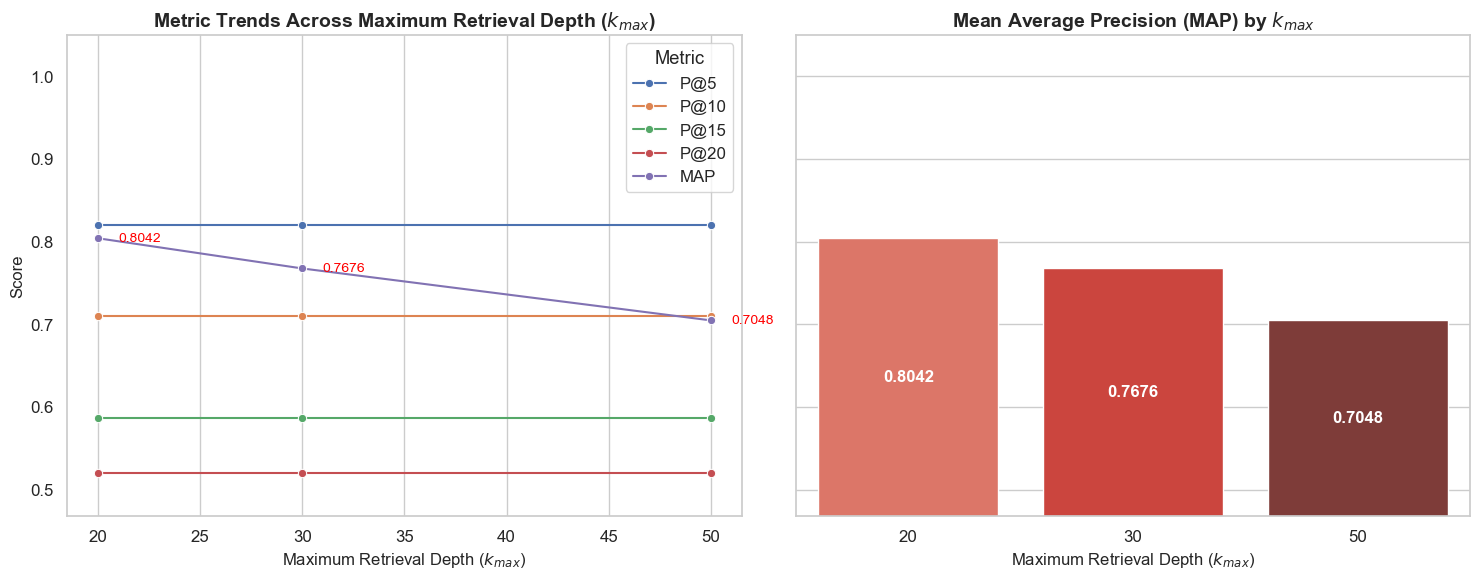

In [14]:
visualize_metrics(dynamic_df)